In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATA
# ============================================================

Proj_Folder = Path.cwd()

input_file = Proj_Folder / "raw" / "SV.csv"

df = pd.read_csv(
    input_file,
    low_memory=False
)

df["epoch"] = pd.to_datetime(
    df["epoch"],
    format="mixed",
    utc=True,
    errors="coerce"
)

SAT_COL = "idOnOrbit"
POS_COLS = ["xpos", "ypos", "zpos"]
VEL_COLS = ["xvel", "yvel", "zvel"]


# ============================================================
# 2. FILTER: USA + GEO
# ============================================================

usa_geo = df[
    (df["country"] == "USA") &
    (df["orbitRegime"] == "GEO")
].copy()

print("=" * 70)
print("USA GEO POPULATION")
print("=" * 70)

print("Rows:", len(usa_geo))
print(
    "Unique satellites:",
    usa_geo[SAT_COL].nunique()
)

print(
    "Date range:",
    usa_geo["epoch"].min(),
    "to",
    usa_geo["epoch"].max()
)

USA GEO POPULATION
Rows: 407924
Unique satellites: 126
Date range: 2025-07-01 00:00:31.107000+00:00 to 2025-07-31 23:59:30.746930+00:00


In [5]:
# ============================================================
# 3. SENSOR + REFERENCE FRAME COVERAGE
# ============================================================

source_frame_summary = (
    usa_geo
    .groupby(
        ["source", "referenceFrame"],
        dropna=False
    )
    .agg(
        observations=(SAT_COL, "size"),
        satellites=(SAT_COL, "nunique")
    )
    .reset_index()
    .sort_values(
        ["satellites", "observations"],
        ascending=False
    )
)

print("\n")
print("=" * 70)
print("USA GEO — SENSOR / FRAME COVERAGE")
print("=" * 70)

N_USA_GEO = usa_geo[SAT_COL].nunique()

source_frame_summary["coverage_percent"] = (
    100 *
    source_frame_summary["satellites"] /
    N_USA_GEO
)

print(
    source_frame_summary[
        [
            "source",
            "referenceFrame",
            "satellites",
            "coverage_percent",
            "observations"
        ]
    ].to_string(
        index=False,
        formatters={
            "coverage_percent":
                lambda x: f"{x:.1f}%"
        }
    )
)
documented_sources = (
    source_frame_summary[
        source_frame_summary[
            "referenceFrame"
        ].notna()
    ]
    .sort_values(
        ["satellites", "observations"],
        ascending=False
    )
)

print("\nBest documented source/frame combinations:")
print(
    documented_sources.head(10)
)



USA GEO — SENSOR / FRAME COVERAGE
   source referenceFrame  satellites coverage_percent  observations
Slingshot            NaN         126           100.0%        290262
NorthStar          J2000         123            97.6%         48758
      EXO            NaN         123            97.6%         28400
      KBR          J2000         122            96.8%         36332
     USNO           TEME          34            27.0%          1145
   SAFRAN            NaN           2             1.6%          3027

Best documented source/frame combinations:
      source referenceFrame  observations  satellites  coverage_percent
2  NorthStar          J2000         48758         123         97.619048
1        KBR          J2000         36332         122         96.825397
5       USNO           TEME          1145          34         26.984127


In [29]:
# ============================================================
# USA GEO SOURCES
# ============================================================

slingshot = usa_geo[
    usa_geo["source"] == "Slingshot"
].copy()

northstar = usa_geo[
    (usa_geo["source"] == "NorthStar") &
    (usa_geo["referenceFrame"] == "J2000")
].copy()

kbr = usa_geo[
    (usa_geo["source"] == "KBR") &
    (usa_geo["referenceFrame"] == "J2000")
].copy()

print("Slingshot satellites:", slingshot[SAT_COL].nunique())
print("NorthStar satellites:", northstar[SAT_COL].nunique())
print("KBR satellites:", kbr[SAT_COL].nunique())
# ============================================================
# PREPARE FOR CROSS-SENSOR COMPARISON
# ============================================================

compare_cols = [
    SAT_COL,
    "epoch",
    "xpos", "ypos", "zpos",
    "xvel", "yvel", "zvel"
]

sling_compare = (
    slingshot[compare_cols]
    .dropna()
    .sort_values([SAT_COL, "epoch"])
    .copy()
)

north_compare = (
    northstar[compare_cols]
    .dropna()
    .sort_values([SAT_COL, "epoch"])
    .copy()
)

# Rename so we know which provider each value came from
sling_compare = sling_compare.rename(columns={
    "epoch": "epoch_sling",
    "xpos": "x_sling",
    "ypos": "y_sling",
    "zpos": "z_sling",
    "xvel": "vx_sling",
    "yvel": "vy_sling",
    "zvel": "vz_sling"
})

north_compare = north_compare.rename(columns={
    "epoch": "epoch_north",
    "xpos": "x_north",
    "ypos": "y_north",
    "zpos": "z_north",
    "xvel": "vx_north",
    "yvel": "vy_north",
    "zvel": "vz_north"
})
matched = pd.merge_asof(
    sling_compare.sort_values("epoch_sling"),
    north_compare.sort_values("epoch_north"),

    left_on="epoch_sling",
    right_on="epoch_north",

    by=SAT_COL,

    direction="nearest",

    tolerance=pd.Timedelta("30s")
)

matched = matched.dropna(
    subset=[
        "x_north",
        "y_north",
        "z_north"
    ]
).copy()

print("Matched observations:", len(matched))
print(
    "Matched satellites:",
    matched[SAT_COL].nunique()
)

Slingshot satellites: 126
NorthStar satellites: 123
KBR satellites: 122
Matched observations: 46562
Matched satellites: 121


In [34]:
# ============================================================
# TIME-CORRECT NORTHSTAR TO THE SLINGSHOT EPOCH
# ============================================================

matched["dt_sec"] = (
    matched["epoch_sling"] -
    matched["epoch_north"]
).dt.total_seconds()


matched["x_north_corrected"] = (
    matched["x_north"]
    + matched["vx_north"] * matched["dt_sec"]
)

matched["y_north_corrected"] = (
    matched["y_north"]
    + matched["vy_north"] * matched["dt_sec"]
)

matched["z_north_corrected"] = (
    matched["z_north"]
    + matched["vz_north"] * matched["dt_sec"]
)
matched["position_difference_km"] = np.sqrt(
    (matched["x_sling"] - matched["x_north_corrected"])**2
    +
    (matched["y_sling"] - matched["y_north_corrected"])**2
    +
    (matched["z_sling"] - matched["z_north_corrected"])**2
)
matched["velocity_difference_kms"] = np.sqrt(
    (matched["vx_sling"] - matched["vx_north"])**2
    +
    (matched["vy_sling"] - matched["vy_north"])**2
    +
    (matched["vz_sling"] - matched["vz_north"])**2
)
sensor_comparison = (
    matched
    .groupby(SAT_COL)
    .agg(
        n_matches=(
            "position_difference_km",
            "size"
        ),

        median_position_diff_km=(
            "position_difference_km",
            "median"
        ),

        p95_position_diff_km=(
            "position_difference_km",
            lambda x: x.quantile(.95)
        ),

        median_velocity_diff_kms=(
            "velocity_difference_kms",
            "median"
        )
    )
)

print(
    sensor_comparison
    .sort_values(
        "median_position_diff_km",
        ascending=False
    )
    .head(5)
)

           n_matches  median_position_diff_km  p95_position_diff_km  \
idOnOrbit                                                             
51280              1             17944.825114          17944.825114   
43226            275               161.727918           9483.521706   
41744              2                68.174362            107.187962   
27566              5                 2.553329              8.032187   
36108            177                 0.760785              9.225698   

           median_velocity_diff_kms  
idOnOrbit                            
51280                      1.314821  
43226                      0.015094  
41744                      0.015726  
27566                      0.001239  
36108                      0.000205  


In [73]:
# ============================================================
# 1. TRUSTED U.S. GEO STATE DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


SAT_COL = "idOnOrbit"

POS_COLS = [
    "xpos",
    "ypos",
    "zpos"
]

VEL_COLS = [
    "xvel",
    "yvel",
    "zvel"
]


TRUSTED_SOURCES = [
    "Slingshot",
    "NorthStar",
    "KBR"
]


# ------------------------------------------------------------
# Known bad source / satellite combinations
# ------------------------------------------------------------

BAD_SOURCE_SAT_PAIRS = {
    ("Slingshot", 43226),   # GOES 17
}


trusted = usa_geo[
    usa_geo["source"].isin(
        TRUSTED_SOURCES
    )
].copy()


# NorthStar / KBR must explicitly be J2000.
# Slingshot was empirically shown to agree closely
# with both J2000 sources.

trusted = trusted[
    (
        trusted["source"] == "Slingshot"
    )
    |
    (
        (
            trusted["source"].isin(
                ["NorthStar", "KBR"]
            )
        )
        &
        (
            trusted["referenceFrame"] == "J2000"
        )
    )
].copy()


# ------------------------------------------------------------
# Remove known bad source-satellite combinations
# ------------------------------------------------------------

for source, sat in BAD_SOURCE_SAT_PAIRS:

    trusted = trusted[
        ~(
            (trusted["source"] == source)
            &
            (trusted[SAT_COL] == sat)
        )
    ]


# ------------------------------------------------------------
# Clean state vectors
# ------------------------------------------------------------

for col in POS_COLS + VEL_COLS:

    trusted[col] = pd.to_numeric(
        trusted[col],
        errors="coerce"
    )


trusted = trusted.dropna(
    subset=[
        "epoch",
        *POS_COLS,
        *VEL_COLS
    ]
)


trusted = (
    trusted
    .sort_values(
        [
            "source",
            SAT_COL,
            "epoch"
        ]
    )
    .drop_duplicates(
        subset=[
            "source",
            SAT_COL,
            "epoch"
        ],
        keep="first"
    )
    .reset_index(drop=True)
)


print("=" * 70)
print("TRUSTED U.S. GEO STATE DATA")
print("=" * 70)

print(
    trusted
    .groupby("source")
    .agg(
        observations=(SAT_COL, "size"),
        satellites=(SAT_COL, "nunique")
    )
)

print(
    "\nTotal U.S. GEO satellites represented:",
    trusted[SAT_COL].nunique()
)
# ============================================================
# 2. TARGET U.S. GEO POPULATION
# ============================================================

USA_SATS = sorted(
    usa_geo[
        SAT_COL
    ]
    .dropna()
    .unique()
)


N_USA = len(
    USA_SATS
)


sat_to_row = {
    sat: i
    for i, sat in enumerate(
        USA_SATS
    )
}


name_lookup = (
    usa_geo[
        [
            SAT_COL,
            "commonName"
        ]
    ]
    .drop_duplicates(
        subset=SAT_COL
    )
    .set_index(
        SAT_COL
    )[
        "commonName"
    ]
    .to_dict()
)


print(
    "Target population:",
    N_USA
)

TRUSTED U.S. GEO STATE DATA
           observations  satellites
source                             
KBR               36304         122
NorthStar         48582         123
Slingshot        283544         125

Total U.S. GEO satellites represented: 126
Target population: 126


In [74]:
# ============================================================
# 3. CANDIDATE COMMON EPOCHS
# ============================================================

TIME_STEP = "10min"


candidate_times = pd.date_range(

    start=
        trusted[
            "epoch"
        ].min().ceil(
            TIME_STEP
        ),

    end=
        trusted[
            "epoch"
        ].max().floor(
            TIME_STEP
        ),

    freq=TIME_STEP
)


candidate_ns = (
    candidate_times.asi8
)


n_times = len(
    candidate_times
)


print(
    "Candidate epochs:",
    n_times
)

print(
    "From:",
    candidate_times.min()
)

print(
    "To:",
    candidate_times.max()
)

Candidate epochs: 4463
From: 2025-07-01 00:10:00+00:00
To: 2025-07-31 23:50:00+00:00


In [75]:
# ============================================================
# 4. RECONSTRUCTION AVAILABILITY
# ============================================================

HERMITE_MAX_GAP_MIN = 60


# ------------------------------------------------------------
# Best Hermite bracket available
# ------------------------------------------------------------

best_hermite_gap = np.full(
    (N_USA, n_times),
    np.inf
)

best_hermite_source = np.full(
    (N_USA, n_times),
    "",
    dtype=object
)


# ------------------------------------------------------------
# Best propagation starting state available
# ------------------------------------------------------------

best_prop_age_min = np.full(
    (N_USA, n_times),
    np.inf
)

best_prop_source = np.full(
    (N_USA, n_times),
    "",
    dtype=object
)

best_prop_epoch_ns = np.full(
    (N_USA, n_times),
    -1,
    dtype=np.int64
)

In [76]:
# ============================================================
# 5. SEARCH EACH SOURCE INDEPENDENTLY
# ============================================================

for source in TRUSTED_SOURCES:

    source_data = trusted[
        trusted["source"] == source
    ]


    print(
        f"Processing {source}: "
        f"{source_data[SAT_COL].nunique()} satellites"
    )


    for sat, group in source_data.groupby(
        SAT_COL
    ):

        row = sat_to_row.get(
            sat
        )

        if row is None:
            continue


        group = (
            group
            .sort_values("epoch")
            .reset_index(drop=True)
        )


        times_ns = (
            group["epoch"]
            .astype("int64")
            .to_numpy()
        )


        if len(
            times_ns
        ) == 0:

            continue


        # ====================================================
        # A. HERMITE BRACKETING
        # ====================================================

        idx_after = np.searchsorted(
            times_ns,
            candidate_ns,
            side="right"
        )


        bracket_valid = (
            (idx_after > 0)
            &
            (idx_after < len(times_ns))
        )


        candidate_idx = np.where(
            bracket_valid
        )[0]


        if len(
            candidate_idx
        ) > 0:

            after_idx = (
                idx_after[
                    bracket_valid
                ]
            )

            before_idx = (
                after_idx - 1
            )


            t_before = times_ns[
                before_idx
            ]

            t_after = times_ns[
                after_idx
            ]

            target = candidate_ns[
                bracket_valid
            ]


            before_gap = (
                target - t_before
            ) / 60e9

            after_gap = (
                t_after - target
            ) / 60e9


            max_gap = np.maximum(
                before_gap,
                after_gap
            )


            valid_hermite = (
                max_gap
                <= HERMITE_MAX_GAP_MIN
            )


            candidate_good = (
                candidate_idx[
                    valid_hermite
                ]
            )


            gaps_good = (
                max_gap[
                    valid_hermite
                ]
            )


            current = (
                best_hermite_gap[
                    row,
                    candidate_good
                ]
            )


            better = (
                gaps_good
                <
                current
            )


            update_idx = (
                candidate_good[
                    better
                ]
            )


            best_hermite_gap[
                row,
                update_idx
            ] = gaps_good[
                better
            ]


            best_hermite_source[
                row,
                update_idx
            ] = source


        # ====================================================
        # B. NEAREST STATE FOR PROPAGATION
        # ====================================================

        idx = np.searchsorted(
            times_ns,
            candidate_ns
        )


        # Candidate previous state index
        prev_idx = np.clip(
            idx - 1,
            0,
            len(times_ns) - 1
        )


        # Candidate next state index
        next_idx = np.clip(
            idx,
            0,
            len(times_ns) - 1
        )


        prev_age_min = np.abs(
            candidate_ns
            - times_ns[
                prev_idx
            ]
        ) / 60e9


        next_age_min = np.abs(
            times_ns[
                next_idx
            ]
            - candidate_ns
        ) / 60e9


        use_prev = (
            prev_age_min
            <=
            next_age_min
        )


        nearest_idx = np.where(
            use_prev,
            prev_idx,
            next_idx
        )


        nearest_age = np.where(
            use_prev,
            prev_age_min,
            next_age_min
        )


        nearest_epoch = (
            times_ns[
                nearest_idx
            ]
        )


        current_age = (
            best_prop_age_min[
                row,
                :
            ]
        )


        better = (
            nearest_age
            <
            current_age
        )


        best_prop_age_min[
            row,
            better
        ] = nearest_age[
            better
        ]


        best_prop_source[
            row,
            better
        ] = source


        best_prop_epoch_ns[
            row,
            better
        ] = nearest_epoch[
            better
        ]

Processing Slingshot: 125 satellites
Processing NorthStar: 123 satellites
Processing KBR: 122 satellites


In [77]:
# ============================================================
# 6. METHOD REQUIRED AT EACH t0
# ============================================================

has_hermite = np.isfinite(
    best_hermite_gap
)


has_propagation_state = np.isfinite(
    best_prop_age_min
)


# Every satellite we can reconstruct somehow
reconstructable = (
    has_hermite
    |
    has_propagation_state
)


# ------------------------------------------------------------
# Propagation age is zero for objects that can use Hermite.
#
# This lets us evaluate how much actual propagation is
# required for the rest of the population.
# ------------------------------------------------------------

required_prop_age = np.where(

    has_hermite,

    0.0,

    best_prop_age_min
)

In [78]:
# ============================================================
# 7. SCORE CANDIDATE t0 VALUES
# ============================================================

quality_rows = []


for j, t in enumerate(
    candidate_times
):

    can_reconstruct = (
        reconstructable[
            :,
            j
        ]
    )


    n_reconstructable = int(
        can_reconstruct.sum()
    )


    n_hermite = int(
        has_hermite[
            :,
            j
        ].sum()
    )


    n_propagated = (
        n_reconstructable
        - n_hermite
    )


    ages = (
        required_prop_age[
            can_reconstruct,
            j
        ]
    )


    if len(
        ages
    ) == 0:

        continue


    quality_rows.append({

        "target_time":
            t,

        "n_reconstructable":
            n_reconstructable,

        "n_hermite":
            n_hermite,

        "n_propagated":
            n_propagated,

        "median_prop_age_min":
            np.median(
                ages
            ),

        "p90_prop_age_min":
            np.quantile(
                ages,
                0.90
            ),

        "p95_prop_age_min":
            np.quantile(
                ages,
                0.95
            ),

        "max_prop_age_min":
            np.max(
                ages
            )
    })


t0_quality = pd.DataFrame(
    quality_rows
)

In [80]:
# ============================================================
# 8. COMPLETE U.S. GEO SNAPSHOTS
# ============================================================

complete = t0_quality[
    t0_quality[
        "n_reconstructable"
    ] == N_USA
].copy()


print("=" * 70)
print("COMPLETE 126-SATELLITE CANDIDATE EPOCHS")
print("=" * 70)

print(
    "Number of complete candidate epochs:",
    len(complete)
)
if len(complete) > 0:

    complete = (
        complete
        .sort_values(

            [
                # First minimize worst-case propagation
                "max_prop_age_min",

                # Then minimize the tail
                "p95_prop_age_min",

                # Then maximize number using interpolation
                "n_hermite",

                # Then minimize typical propagation
                "median_prop_age_min"
            ],

            ascending=[
                True,
                True,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )


    print("\nTOP 20 COMPLETE CANDIDATE EPOCHS")
    print("=" * 70)

    print(
        complete
        .head(20)
        .to_string(index=False)
    )

COMPLETE 126-SATELLITE CANDIDATE EPOCHS
Number of complete candidate epochs: 4463

TOP 20 COMPLETE CANDIDATE EPOCHS
              target_time  n_reconstructable  n_hermite  n_propagated  median_prop_age_min  p90_prop_age_min  p95_prop_age_min  max_prop_age_min
2025-07-15 09:30:00+00:00                126         53            73            21.337263        406.698299        551.390658       2368.201567
2025-07-15 09:20:00+00:00                126         49            77            28.146566        396.698299        541.390658       2370.781713
2025-07-15 09:40:00+00:00                126         53            73            11.412193        416.698299        561.390658       2378.201567
2025-07-15 09:10:00+00:00                126         45            81            23.330875        386.698299        535.605392       2380.781713
2025-07-15 09:50:00+00:00                126         53            73             7.179464        418.756696        571.390658       2388.201567
2025-07-15 09:

In [81]:
# ============================================================
# 9. PROVISIONAL OPTIMAL t0
# ============================================================

if len(complete) == 0:

    print(
        "No candidate epoch can reconstruct all 126 "
        "from the trusted sources."
    )

else:

    best_t0_row = (
        complete.iloc[0]
    )

    best_t0 = (
        best_t0_row[
            "target_time"
        ]
    )


    best_t0_idx = (
        candidate_times.get_loc(
            best_t0
        )
    )


    print("\n")
    print("=" * 70)
    print("PROVISIONAL OPTIMAL t0")
    print("=" * 70)

    print(
        best_t0_row
    )



PROVISIONAL OPTIMAL t0
target_time            2025-07-15 09:30:00+00:00
n_reconstructable                            126
n_hermite                                     53
n_propagated                                  73
median_prop_age_min                    21.337263
p90_prop_age_min                      406.698299
p95_prop_age_min                      551.390658
max_prop_age_min                     2368.201567
Name: 0, dtype: object


In [82]:
# ============================================================
# 10. RECONSTRUCTION PLAN AT PROVISIONAL t0
# ============================================================

reconstruction_rows = []


for i, sat in enumerate(
    USA_SATS
):


    if has_hermite[
        i,
        best_t0_idx
    ]:

        method = "Hermite"

        source = (
            best_hermite_source[
                i,
                best_t0_idx
            ]
        )

        age_min = (
            best_hermite_gap[
                i,
                best_t0_idx
            ]
        )


    else:

        method = "Propagation"

        source = (
            best_prop_source[
                i,
                best_t0_idx
            ]
        )

        age_min = (
            best_prop_age_min[
                i,
                best_t0_idx
            ]
        )


    reconstruction_rows.append({

        SAT_COL:
            sat,

        "commonName":
            name_lookup.get(
                sat,
                ""
            ),

        "method":
            method,

        "source":
            source,

        "time_distance_min":
            age_min,

        "time_distance_hr":
            age_min / 60
    })


reconstruction_plan = pd.DataFrame(
    reconstruction_rows
)


print("\n")
print("=" * 70)
print("RECONSTRUCTION PLAN")
print("=" * 70)


print(
    reconstruction_plan[
        "method"
    ].value_counts()
)


print("\nPropagation age:")
print(
    reconstruction_plan[
        reconstruction_plan[
            "method"
        ] == "Propagation"
    ][
        "time_distance_hr"
    ].describe()
)



RECONSTRUCTION PLAN
method
Propagation    73
Hermite        53
Name: count, dtype: int64

Propagation age:
count    73.000000
mean      5.110115
std       7.261511
min       0.021886
25%       0.598953
50%       3.556982
75%       6.031512
max      39.470026
Name: time_distance_hr, dtype: float64


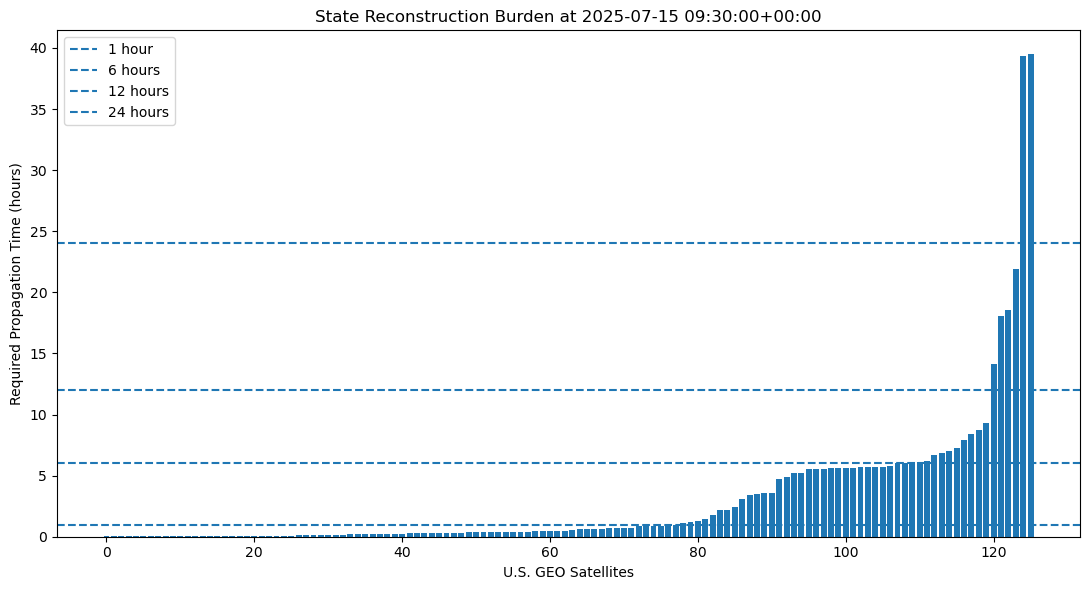

In [83]:
# ============================================================
# 11. PROPAGATION BURDEN
# ============================================================

plot_plan = (
    reconstruction_plan
    .sort_values(
        "time_distance_hr"
    )
    .reset_index(drop=True)
)


plt.figure(
    figsize=(11, 6)
)


plt.bar(
    np.arange(
        len(plot_plan)
    ),
    plot_plan[
        "time_distance_hr"
    ]
)


plt.axhline(
    1,
    linestyle="--",
    label="1 hour"
)

plt.axhline(
    6,
    linestyle="--",
    label="6 hours"
)

plt.axhline(
    12,
    linestyle="--",
    label="12 hours"
)

plt.axhline(
    24,
    linestyle="--",
    label="24 hours"
)


plt.xlabel(
    "U.S. GEO Satellites"
)

plt.ylabel(
    "Required Propagation Time (hours)"
)

plt.title(
    f"State Reconstruction Burden at {best_t0}"
)

plt.legend()

plt.tight_layout()

plt.show()

In [84]:
# ============================================================
# 12. J2 ORBITAL PROPAGATOR
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp


# Earth constants
# Units: km, seconds

MU_EARTH = 398600.4418       # km^3 / s^2
R_EARTH = 6378.1363          # km
J2_EARTH = 1.08262668e-3


def j2_dynamics(t, state):
    """
    Earth two-body gravity + J2 perturbation.

    State:
        [x, y, z, vx, vy, vz]

    Position: km
    Velocity: km/s
    """

    x, y, z, vx, vy, vz = state

    r_vec = np.array(
        [x, y, z],
        dtype=float
    )

    r = np.linalg.norm(
        r_vec
    )

    if r == 0:
        raise ValueError(
            "Zero position magnitude."
        )


    # --------------------------------------------------------
    # Central gravity
    # --------------------------------------------------------

    a_central = (
        -MU_EARTH
        * r_vec
        / r**3
    )


    # --------------------------------------------------------
    # J2 perturbation
    # --------------------------------------------------------

    z2_over_r2 = (
        z**2 / r**2
    )

    factor = (
        1.5
        * J2_EARTH
        * MU_EARTH
        * R_EARTH**2
        / r**5
    )


    a_j2 = factor * np.array([

        x * (
            5*z2_over_r2 - 1
        ),

        y * (
            5*z2_over_r2 - 1
        ),

        z * (
            5*z2_over_r2 - 3
        )
    ])


    acceleration = (
        a_central
        +
        a_j2
    )


    return np.array([

        vx,
        vy,
        vz,

        acceleration[0],
        acceleration[1],
        acceleration[2]
    ])

In [85]:
# ============================================================
# PROPAGATE ONE STATE
# ============================================================

def propagate_j2(
    r0,
    v0,
    dt_sec
):
    """
    Propagate one Cartesian state by dt_sec.

    dt_sec may be positive or negative.

    Returns
    -------
    r_final : km
    v_final : km/s
    """

    state0 = np.concatenate([
        np.asarray(
            r0,
            dtype=float
        ),
        np.asarray(
            v0,
            dtype=float
        )
    ])


    solution = solve_ivp(

        fun=j2_dynamics,

        t_span=(
            0.0,
            float(dt_sec)
        ),

        y0=state0,

        method="DOP853",

        rtol=1e-10,

        atol=1e-11,

        # 15-minute maximum integration step
        max_step=900.0
    )


    if not solution.success:

        raise RuntimeError(
            solution.message
        )


    final_state = (
        solution.y[:, -1]
    )


    return (
        final_state[:3],
        final_state[3:]
    )

In [86]:
# ============================================================
# 13. PROPAGATOR SANITY TEST
# ============================================================

test_row = (
    trusted
    .iloc[0]
)


r0 = test_row[
    POS_COLS
].to_numpy(
    dtype=float
)


v0 = test_row[
    VEL_COLS
].to_numpy(
    dtype=float
)


r1, v1 = propagate_j2(
    r0,
    v0,
    24 * 3600
)


print(
    "Initial radius:",
    np.linalg.norm(r0),
    "km"
)

print(
    "Final radius:",
    np.linalg.norm(r1),
    "km"
)

print(
    "Initial speed:",
    np.linalg.norm(v0),
    "km/s"
)

print(
    "Final speed:",
    np.linalg.norm(v1),
    "km/s"
)

Initial radius: 42132.32734782297 km
Final radius: 42129.794699079626 km
Initial speed: 3.0770166965850514 km/s
Final speed: 3.077201525753394 km/s


In [88]:
# ============================================================
# 14. PROPAGATION VALIDATION DATA
# ============================================================

prop_validation_data = (
    trusted
    .copy()
)


prop_validation_data[
    "radius_km"
] = np.sqrt(

    prop_validation_data[
        "xpos"
    ]**2

    +

    prop_validation_data[
        "ypos"
    ]**2

    +

    prop_validation_data[
        "zpos"
    ]**2
)


prop_validation_data[
    "speed_kms"
] = np.sqrt(

    prop_validation_data[
        "xvel"
    ]**2

    +

    prop_validation_data[
        "yvel"
    ]**2

    +

    prop_validation_data[
        "zvel"
    ]**2
)


# Broad sanity filtering only
prop_validation_data = (
    prop_validation_data[

        prop_validation_data[
            "radius_km"
        ].between(
            35000,
            50000
        )

        &

        prop_validation_data[
            "speed_kms"
        ].between(
            2.5,
            3.5
        )
    ]
    .copy()
)


print(
    prop_validation_data
    .groupby("source")
    .agg(
        observations=(
            SAT_COL,
            "size"
        ),
        satellites=(
            SAT_COL,
            "nunique"
        )
    )
)

           observations  satellites
source                             
KBR               36304         122
NorthStar         48582         123
Slingshot        283544         125


In [90]:
# ============================================================
# 14. PROPAGATION VALIDATION DATA
# ============================================================

prop_validation_data = (
    trusted
    .copy()
)


prop_validation_data[
    "radius_km"
] = np.sqrt(

    prop_validation_data[
        "xpos"
    ]**2

    +

    prop_validation_data[
        "ypos"
    ]**2

    +

    prop_validation_data[
        "zpos"
    ]**2
)


prop_validation_data[
    "speed_kms"
] = np.sqrt(

    prop_validation_data[
        "xvel"
    ]**2

    +

    prop_validation_data[
        "yvel"
    ]**2

    +

    prop_validation_data[
        "zvel"
    ]**2
)


# Broad sanity filtering only
prop_validation_data = (
    prop_validation_data[

        prop_validation_data[
            "radius_km"
        ].between(
            35000,
            50000
        )

        &

        prop_validation_data[
            "speed_kms"
        ].between(
            2.5,
            3.5
        )
    ]
    .copy()
)


print(
    prop_validation_data
    .groupby("source")
    .agg(
        observations=(
            SAT_COL,
            "size"
        ),
        satellites=(
            SAT_COL,
            "nunique"
        )
    )
)

           observations  satellites
source                             
KBR               36304         122
NorthStar         48582         123
Slingshot        283544         125


In [91]:
# ============================================================
# 15. BUILD PROPAGATION VALIDATION PAIRS
# ============================================================

HORIZONS_HR = [
    1,
    3,
    6,
    12,
    24,
    36,
    48
]


# Allowed difference between requested horizon
# and the actual observation separation

HORIZON_TOLERANCE_HR = {

    1: 0.25,
    3: 0.50,
    6: 0.75,
    12: 1.0,
    24: 2.0,
    36: 3.0,
    48: 4.0
}


RANDOM_STATE = 42

rng = np.random.default_rng(
    RANDOM_STATE
)


validation_pairs = []


for source in TRUSTED_SOURCES:

    source_data = (
        prop_validation_data[
            prop_validation_data[
                "source"
            ] == source
        ]
    )


    for sat, group in source_data.groupby(
        SAT_COL
    ):

        group = (
            group
            .sort_values("epoch")
            .reset_index(drop=True)
        )


        if len(group) < 2:
            continue


        times_ns = (
            group["epoch"]
            .astype("int64")
            .to_numpy()
        )


        positions = (
            group[
                POS_COLS
            ]
            .to_numpy(
                dtype=float
            )
        )


        velocities = (
            group[
                VEL_COLS
            ]
            .to_numpy(
                dtype=float
            )
        )


        for horizon_hr in HORIZONS_HR:

            horizon_ns = int(
                horizon_hr
                * 3600
                * 1e9
            )


            tolerance_hr = (
                HORIZON_TOLERANCE_HR[
                    horizon_hr
                ]
            )


            # ---------------------------------------------
            # Starting observations that leave enough
            # time for the requested horizon
            # ---------------------------------------------

            latest_start = (
                times_ns[-1]
                - horizon_ns
            )


            possible_starts = np.where(
                times_ns
                <= latest_start
            )[0]


            if len(
                possible_starts
            ) == 0:

                continue


            # Randomly choose one start for this
            # satellite/source/horizon
            start_idx = rng.choice(
                possible_starts
            )


            desired_target = (
                times_ns[
                    start_idx
                ]
                +
                horizon_ns
            )


            j = np.searchsorted(
                times_ns,
                desired_target
            )


            candidate_targets = []


            if (
                j < len(times_ns)
                and
                j > start_idx
            ):

                candidate_targets.append(
                    j
                )


            if (
                j - 1 > start_idx
            ):

                candidate_targets.append(
                    j - 1
                )


            if len(
                candidate_targets
            ) == 0:

                continue


            # Pick actual observation closest
            # to desired horizon
            target_idx = min(

                candidate_targets,

                key=lambda k:
                    abs(
                        times_ns[k]
                        -
                        desired_target
                    )
            )


            actual_dt_hr = (
                times_ns[
                    target_idx
                ]
                -
                times_ns[
                    start_idx
                ]
            ) / 3.6e12


            # Ensure observation is actually close
            # enough to requested horizon
            if (
                abs(
                    actual_dt_hr
                    -
                    horizon_hr
                )
                >
                tolerance_hr
            ):

                continue


            validation_pairs.append({

                "source":
                    source,

                SAT_COL:
                    sat,

                "commonName":
                    group.iloc[
                        start_idx
                    ]["commonName"],

                "start_epoch":
                    group.iloc[
                        start_idx
                    ]["epoch"],

                "target_epoch":
                    group.iloc[
                        target_idx
                    ]["epoch"],

                "target_horizon_hr":
                    horizon_hr,

                "actual_dt_hr":
                    actual_dt_hr,

                "r0x":
                    positions[
                        start_idx,
                        0
                    ],

                "r0y":
                    positions[
                        start_idx,
                        1
                    ],

                "r0z":
                    positions[
                        start_idx,
                        2
                    ],

                "v0x":
                    velocities[
                        start_idx,
                        0
                    ],

                "v0y":
                    velocities[
                        start_idx,
                        1
                    ],

                "v0z":
                    velocities[
                        start_idx,
                        2
                    ],

                "true_x":
                    positions[
                        target_idx,
                        0
                    ],

                "true_y":
                    positions[
                        target_idx,
                        1
                    ],

                "true_z":
                    positions[
                        target_idx,
                        2
                    ],

                "true_vx":
                    velocities[
                        target_idx,
                        0
                    ],

                "true_vy":
                    velocities[
                        target_idx,
                        1
                    ],

                "true_vz":
                    velocities[
                        target_idx,
                        2
                    ]
            })


validation_pairs = pd.DataFrame(
    validation_pairs
)


print(
    "Validation pairs:",
    len(validation_pairs)
)


print(
    "\nPairs by requested horizon:"
)

print(
    validation_pairs[
        "target_horizon_hr"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nSatellites represented:",
    validation_pairs[
        SAT_COL
    ].nunique()
)

Validation pairs: 1322

Pairs by requested horizon:
target_horizon_hr
1     234
3     194
6     134
12     39
24    297
36    111
48    313
Name: count, dtype: int64

Satellites represented: 125


In [92]:
# ============================================================
# 16. RUN J2 PROPAGATION VALIDATION
# ============================================================

propagation_results = []


N = len(
    validation_pairs
)


for count, row in enumerate(
    validation_pairs.itertuples(
        index=False
    ),
    start=1
):


    r0 = np.array([
        row.r0x,
        row.r0y,
        row.r0z
    ])


    v0 = np.array([
        row.v0x,
        row.v0y,
        row.v0z
    ])


    r_true = np.array([
        row.true_x,
        row.true_y,
        row.true_z
    ])


    v_true = np.array([
        row.true_vx,
        row.true_vy,
        row.true_vz
    ])


    dt_sec = (
        row.actual_dt_hr
        * 3600
    )


    try:

        r_pred, v_pred = (
            propagate_j2(
                r0,
                v0,
                dt_sec
            )
        )


        position_error_km = (
            np.linalg.norm(
                r_pred
                -
                r_true
            )
        )


        velocity_error_kms = (
            np.linalg.norm(
                v_pred
                -
                v_true
            )
        )


        propagation_results.append({

            "source":
                row.source,

            SAT_COL:
                getattr(
                    row,
                    SAT_COL
                ),

            "commonName":
                row.commonName,

            "start_epoch":
                row.start_epoch,

            "target_epoch":
                row.target_epoch,

            "target_horizon_hr":
                row.target_horizon_hr,

            "actual_dt_hr":
                row.actual_dt_hr,

            "position_error_km":
                position_error_km,

            "velocity_error_kms":
                velocity_error_kms
        })


    except Exception as e:

        print(
            "Propagation failed:",
            row.source,
            getattr(
                row,
                SAT_COL
            ),
            row.actual_dt_hr,
            e
        )


    if (
        count % 250 == 0
        or
        count == N
    ):

        print(
            f"Completed {count}/{N}"
        )


propagation_results = pd.DataFrame(
    propagation_results
)


print(
    "\nSuccessful validations:",
    len(propagation_results)
)

Completed 250/1322
Completed 500/1322
Completed 750/1322
Completed 1000/1322
Completed 1250/1322
Completed 1322/1322

Successful validations: 1322


In [93]:
# ============================================================
# 17. PROPAGATION ERROR BY HORIZON
# ============================================================

prop_summary = (
    propagation_results
    .groupby(
        "target_horizon_hr"
    )
    .agg(

        n=(
            "position_error_km",
            "size"
        ),

        satellites=(
            SAT_COL,
            "nunique"
        ),

        median_position_error_km=(
            "position_error_km",
            "median"
        ),

        p90_position_error_km=(
            "position_error_km",
            lambda x:
                x.quantile(
                    0.90
                )
        ),

        p95_position_error_km=(
            "position_error_km",
            lambda x:
                x.quantile(
                    0.95
                )
        ),

        p99_position_error_km=(
            "position_error_km",
            lambda x:
                x.quantile(
                    0.99
                )
        ),

        median_velocity_error_kms=(
            "velocity_error_kms",
            "median"
        )
    )
)


print("\n")
print("=" * 70)
print("J2 PROPAGATION VALIDATION")
print("=" * 70)

print(
    prop_summary
    .to_string()
)



J2 PROPAGATION VALIDATION
                     n  satellites  median_position_error_km  p90_position_error_km  p95_position_error_km  p99_position_error_km  median_velocity_error_kms
target_horizon_hr                                                                                                                                           
1                  234         113                  0.082061               0.392699               0.718517               2.750829                   0.000025
3                  194         104                  0.448249               1.265654               2.189173               5.175422                   0.000069
6                  134          86                  1.531099               4.115689               6.579958              27.343982                   0.000139
12                  39          32                  7.175203              18.038198              27.631424              40.036856                   0.000434
24                 297        

In [94]:
# ============================================================
# 18. PROPAGATION ERROR BY SOURCE
# ============================================================

source_prop_summary = (
    propagation_results
    .groupby(
        [
            "source",
            "target_horizon_hr"
        ]
    )
    .agg(

        n=(
            "position_error_km",
            "size"
        ),

        satellites=(
            SAT_COL,
            "nunique"
        ),

        median_error_km=(
            "position_error_km",
            "median"
        ),

        p95_error_km=(
            "position_error_km",
            lambda x:
                x.quantile(
                    0.95
                )
        ),

        p99_error_km=(
            "position_error_km",
            lambda x:
                x.quantile(
                    0.99
                )
        )
    )
)


print(
    source_prop_summary
    .to_string()
)

                               n  satellites  median_error_km  p95_error_km  p99_error_km
source    target_horizon_hr                                                              
KBR       1                   71          71         0.053806      0.142080      0.178335
          3                   50          50         0.329886      0.669269      0.748562
          6                   41          41         1.342619      2.661246      2.797781
          12                  13          13         6.836368     15.358586     21.016120
          24                  84          84         7.035708     14.859555     17.191361
          36                  35          35         9.632660     23.271198     24.865655
          48                  85          85        11.839631     35.511740     39.494074
NorthStar 1                   73          73         0.096762      1.447291   7728.263195
          3                   65          65         0.489566      4.571899      5.855144
          

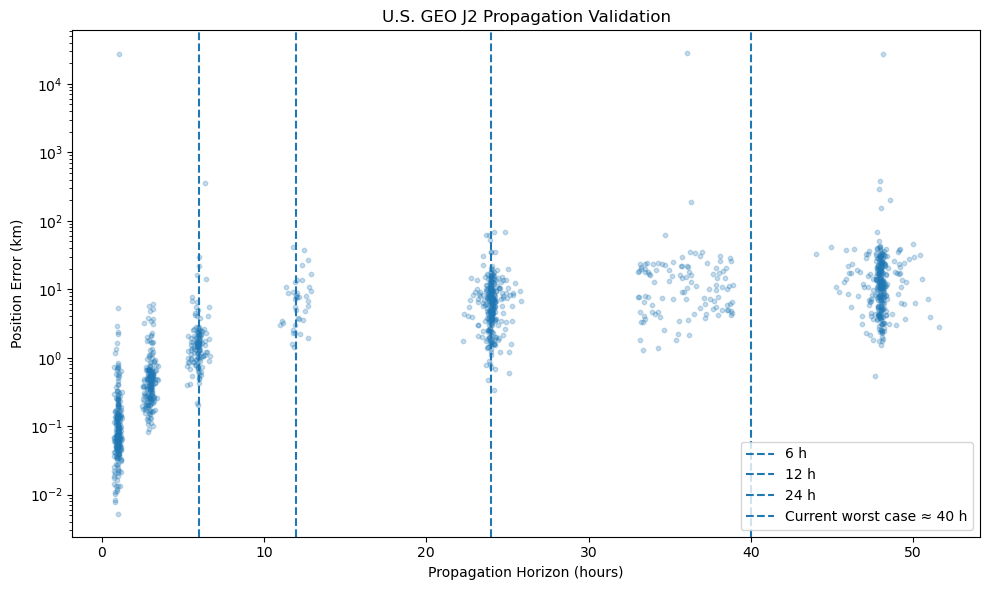

In [95]:
# ============================================================
# 19. PROPAGATION VALIDATION PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.scatter(

    propagation_results[
        "actual_dt_hr"
    ],

    propagation_results[
        "position_error_km"
    ],

    s=10,

    alpha=0.25
)


plt.xlabel(
    "Propagation Horizon (hours)"
)

plt.ylabel(
    "Position Error (km)"
)

plt.title(
    "U.S. GEO J2 Propagation Validation"
)


plt.yscale(
    "log"
)


plt.axvline(
    6,
    linestyle="--",
    label="6 h"
)


plt.axvline(
    12,
    linestyle="--",
    label="12 h"
)


plt.axvline(
    24,
    linestyle="--",
    label="24 h"
)


plt.axvline(
    40,
    linestyle="--",
    label="Current worst case ≈ 40 h"
)


plt.legend()

plt.tight_layout()

plt.show()

In [96]:
# ============================================================
# 20. PROPAGATION OUTLIERS
# ============================================================

print("\nWorst propagation cases:")

print(
    propagation_results
    .sort_values(
        "position_error_km",
        ascending=False
    )
    .head(30)[
        [
            SAT_COL,
            "commonName",
            "source",
            "actual_dt_hr",
            "position_error_km",
            "velocity_error_kms"
        ]
    ]
    .to_string(
        index=False
    )
)


Worst propagation cases:
 idOnOrbit             commonName    source  actual_dt_hr  position_error_km  velocity_error_kms
     44481       AEHF 5 (USA 292) NorthStar     36.038516       27901.129939            2.016811
     44481       AEHF 5 (USA 292) NorthStar      1.099519       27594.877578            2.018810
     44481       AEHF 5 (USA 292) NorthStar     48.164166       27401.783011            2.005278
     28158                USA 176 NorthStar     47.922912         383.747904            0.029542
     51281                USA 325 NorthStar      6.345537         361.059133            0.022640
     43226                GOES 17 NorthStar     47.919237         287.115303            0.021111
     27854 GALAXY 23 (TELSTAR 13) NorthStar     48.547341         199.215199            0.014288
     41879        WGS 8 (USA 272) NorthStar     36.301560         190.802460            0.001763
     27854 GALAXY 23 (TELSTAR 13) Slingshot     48.028282         152.780625            0.010734
    

In [97]:
# ============================================================
# SATELLITES WITH REPEATED LARGE PROPAGATION ERROR
# ============================================================

large_error = (
    propagation_results[
        propagation_results[
            "position_error_km"
        ] > 50
    ]
)


print(
    "\nCases > 50 km:",
    len(large_error)
)


print(
    "\nMost common satellites:"
)

print(
    large_error[
        [
            SAT_COL,
            "commonName"
        ]
    ]
    .value_counts()
    .head(20)
)


Cases > 50 km: 17

Most common satellites:
idOnOrbit  commonName            
27854      GALAXY 23 (TELSTAR 13)    3
44481      AEHF 5 (USA 292)          3
43226      GOES 17                   2
28158      USA 176                   1
36108      WGS F3 (USA 211)          1
39070      TDRS 11                   1
39206      MUOS 2                    1
41592      ECHOSTAR 18               1
41745      USA 271                   1
41879      WGS 8 (USA 272)           1
42740      VIASAT 2                  1
51281      USA 325                   1
Name: count, dtype: int64


In [99]:
# ============================================================
# 21. SOURCE-SATELLITE PROPAGATION RELIABILITY
# ============================================================

source_sat_quality = (
    propagation_results
    .groupby(
        [
            "source",
            SAT_COL,
            "commonName"
        ]
    )
    .agg(

        n_tests=(
            "position_error_km",
            "size"
        ),

        median_error_km=(
            "position_error_km",
            "median"
        ),

        p95_error_km=(
            "position_error_km",
            lambda x:
                x.quantile(0.95)
        ),

        max_error_km=(
            "position_error_km",
            "max"
        ),

        pct_gt_10km=(
            "position_error_km",
            lambda x:
                100 * (x > 10).mean()
        ),

        pct_gt_50km=(
            "position_error_km",
            lambda x:
                100 * (x > 50).mean()
        ),

        pct_gt_100km=(
            "position_error_km",
            lambda x:
                100 * (x > 100).mean()
        )
    )
    .reset_index()
)


print("\n")
print("=" * 90)
print("WORST SOURCE-SATELLITE PAIRS")
print("=" * 90)


print(
    source_sat_quality
    .sort_values(
        "median_error_km",
        ascending=False
    )
    .head(30)
    .to_string(index=False)
)
# ============================================================
# REPEATED CATASTROPHIC SOURCE-SATELLITE PAIRS
# ============================================================

suspect_pairs = source_sat_quality[
    (
        source_sat_quality["n_tests"] >= 2
    )
    &
    (
        (
            source_sat_quality[
                "median_error_km"
            ] > 50
        )
        |
        (
            source_sat_quality[
                "pct_gt_50km"
            ] >= 25
        )
    )
].copy()


print("\n")
print("=" * 90)
print("SUSPECT SOURCE-SATELLITE PAIRS")
print("=" * 90)

print(
    suspect_pairs
    .sort_values(
        [
            "median_error_km",
            "pct_gt_50km"
        ],
        ascending=False
    )
    .to_string(index=False)
)



WORST SOURCE-SATELLITE PAIRS
   source  idOnOrbit             commonName  n_tests  median_error_km  p95_error_km  max_error_km  pct_gt_10km  pct_gt_50km  pct_gt_100km
NorthStar      44481       AEHF 5 (USA 292)        5     27401.783011  27839.879467  27901.129939    80.000000    60.000000     60.000000
NorthStar      27854 GALAXY 23 (TELSTAR 13)        4        53.679479    179.757275    199.215199    75.000000    50.000000     25.000000
Slingshot      41744                USA 270        1        46.561785     46.561785     46.561785   100.000000     0.000000      0.000000
Slingshot      26388                 TDRS 8        1        38.563613     38.563613     38.563613   100.000000     0.000000      0.000000
NorthStar      21639                 TDRS 5        1        33.800512     33.800512     33.800512   100.000000     0.000000      0.000000
      KBR      27691                USA 167        1        33.408430     33.408430     33.408430   100.000000     0.000000      0.000000
   

In [100]:
# ============================================================
# 22. COMPARE SUSPECT SATELLITES ACROSS SOURCES
# ============================================================

SUSPECT_SATS = sorted(
    suspect_pairs[
        SAT_COL
    ].unique()
)


suspect_source_comparison = (
    source_sat_quality[
        source_sat_quality[
            SAT_COL
        ].isin(
            SUSPECT_SATS
        )
    ]
    .sort_values(
        [
            SAT_COL,
            "source"
        ]
    )
)


print(
    suspect_source_comparison
    .to_string(index=False)
)

   source  idOnOrbit             commonName  n_tests  median_error_km  p95_error_km  max_error_km  pct_gt_10km  pct_gt_50km  pct_gt_100km
      KBR      27854 GALAXY 23 (TELSTAR 13)        2         4.267522      5.159339      5.258430     0.000000     0.000000      0.000000
NorthStar      27854 GALAXY 23 (TELSTAR 13)        4        53.679479    179.757275    199.215199    75.000000    50.000000     25.000000
Slingshot      27854 GALAXY 23 (TELSTAR 13)        3         8.066797    138.309242    152.780625    33.333333    33.333333     33.333333
      KBR      28158                USA 176        3         4.308339     13.312889     14.313394    33.333333     0.000000      0.000000
NorthStar      28158                USA 176        3        18.013910    347.174505    383.747904   100.000000    33.333333     33.333333
Slingshot      28158                USA 176        4         4.893834     16.133032     17.535179    25.000000     0.000000      0.000000
      KBR      36108       WGS F3 

In [101]:
# ============================================================
# 23. PROPAGATION BURDEN CATEGORIES AT CURRENT t0
# ============================================================

prop_plan = reconstruction_plan[
    reconstruction_plan[
        "method"
    ] == "Propagation"
].copy()


def propagation_category(hours):

    if hours <= 1:
        return "0-1 h"

    elif hours <= 3:
        return "1-3 h"

    elif hours <= 6:
        return "3-6 h"

    elif hours <= 12:
        return "6-12 h"

    elif hours <= 24:
        return "12-24 h"

    elif hours <= 36:
        return "24-36 h"

    elif hours <= 48:
        return "36-48 h"

    else:
        return ">48 h"


prop_plan[
    "propagation_bin"
] = (
    prop_plan[
        "time_distance_hr"
    ]
    .apply(
        propagation_category
    )
)


bin_order = [
    "0-1 h",
    "1-3 h",
    "3-6 h",
    "6-12 h",
    "12-24 h",
    "24-36 h",
    "36-48 h",
    ">48 h"
]


print("\n")
print("=" * 70)
print("PROPAGATION REQUIREMENT AT CURRENT t0")
print("=" * 70)


print(
    prop_plan[
        "propagation_bin"
    ]
    .value_counts()
    .reindex(
        bin_order,
        fill_value=0
    )
)



PROPAGATION REQUIREMENT AT CURRENT t0
propagation_bin
0-1 h      25
1-3 h       8
3-6 h      21
6-12 h     13
12-24 h     4
24-36 h     0
36-48 h     2
>48 h       0
Name: count, dtype: int64


In [102]:
# ============================================================
# SATELLITES REQUIRING > 6 HOURS
# ============================================================

hard_prop = (
    prop_plan[
        prop_plan[
            "time_distance_hr"
        ] > 6
    ]
    .sort_values(
        "time_distance_hr",
        ascending=False
    )
)


print("\n")
print("=" * 90)
print("SATELLITES REQUIRING > 6 HOURS PROPAGATION")
print("=" * 90)


print(
    hard_prop[
        [
            SAT_COL,
            "commonName",
            "source",
            "time_distance_hr"
        ]
    ]
    .to_string(index=False)
)



SATELLITES REQUIRING > 6 HOURS PROPAGATION
 idOnOrbit             commonName    source  time_distance_hr
     43445                USA 285 Slingshot         39.470026
     48618  SBIRS GEO 5 (USA 315) NorthStar         39.346362
     28158                USA 176       KBR         21.895445
     26388                 TDRS 8 Slingshot         18.561727
     28117       UFO 11 (USA 174) Slingshot         18.025546
     42740               VIASAT 2       KBR         14.110790
     25501        UFO 9 (USA 140) Slingshot          9.329217
     22563         UFO 1 (USA 98)       KBR          8.771726
     40101                USA 255       KBR          8.386042
     23754             ECHOSTAR 1 Slingshot          7.904275
     55264                LDPE-3A Slingshot          7.239675
     51287                 ASCENT Slingshot          7.049858
     46113                  MEV-2 Slingshot          6.837729
     23696        UFO 6 (USA 114) Slingshot          6.718881
     22787         UFO 2 



PROPAGATION UNCERTAINTY CURVE
 hours  raw_p95_km  p95_bound_km
     1    0.718517      0.718517
     3    2.189173      2.189173
     6    6.579958      6.579958
    12   27.631424     27.631424
    24   18.837688     27.631424
    36   32.205228     32.205228
    48   38.784841     38.784841


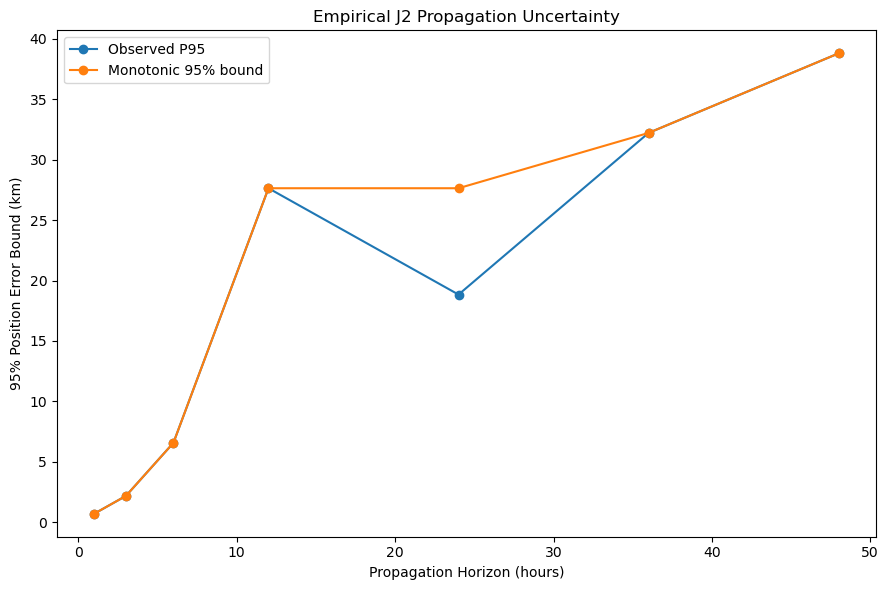

In [104]:
# ============================================================
# 24. MONOTONIC 95% PROPAGATION UNCERTAINTY CURVE
# ============================================================

uncertainty_curve = (
    prop_summary[
        [
            "p95_position_error_km"
        ]
    ]
    .reset_index()
    .rename(
        columns={
            "target_horizon_hr":
                "hours",

            "p95_position_error_km":
                "raw_p95_km"
        }
    )
    .sort_values(
        "hours"
    )
    .reset_index(drop=True)
)


# Force the empirical uncertainty bound
# to be monotonically non-decreasing

uncertainty_curve[
    "p95_bound_km"
] = np.maximum.accumulate(

    uncertainty_curve[
        "raw_p95_km"
    ].to_numpy()
)


print("\n")
print("=" * 70)
print("PROPAGATION UNCERTAINTY CURVE")
print("=" * 70)

print(
    uncertainty_curve
    .to_string(index=False)
)
# ============================================================
# PROPAGATION UNCERTAINTY CURVE PLOT
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    uncertainty_curve[
        "hours"
    ],
    uncertainty_curve[
        "raw_p95_km"
    ],
    marker="o",
    label="Observed P95"
)


plt.plot(
    uncertainty_curve[
        "hours"
    ],
    uncertainty_curve[
        "p95_bound_km"
    ],
    marker="o",
    label="Monotonic 95% bound"
)


plt.xlabel(
    "Propagation Horizon (hours)"
)

plt.ylabel(
    "95% Position Error Bound (km)"
)

plt.title(
    "Empirical J2 Propagation Uncertainty"
)

plt.legend()

plt.tight_layout()

plt.show()

In [105]:
# ============================================================
# 25. HERMITE 95% UNCERTAINTY TABLE
# ============================================================

hermite_uncertainty = pd.DataFrame({

    "max_gap_min": [
        15,
        30,
        60
    ],

    "p95_error_km": [
        0.168440,
        0.309019,
        2.239650
    ]
})


print(
    hermite_uncertainty
)

   max_gap_min  p95_error_km
0           15      0.168440
1           30      0.309019
2           60      2.239650
